In [2]:
!pwd

/users/khordadi/truejit/evaluation/compilation-plan


In [3]:
import os
import sys
from pathlib import Path
from solver import *
from profiling import *
import numpy as np

In [ ]:
plans = []
for mode in compilation_plans:
    plan = solver_output_as_df(f'/tmp/truejit/CAPER/results/gcc-loops.{mode}.json')
    plan = plan['mode.solver'].plans_titles()
    plans.append((mode, plan))

fns_size = len(plans[0][1])

# prepend plan for jit and interp
plans.insert(0, ('interp', ['interpret'] * fns_size))
plans.insert(0, ('jit', ['jit'] * fns_size))

print(f'Number of functions: {fns_size}')
assert all(len(plan) == fns_size for _, plan in plans), "Not all plans have the same length"

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Your data lists
data = [plan for _, plan in plans]
modes = [mode for mode, _ in plans]

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns

mapping = {'interpret': 0, 'specialized': 1, 'static': 2, 'async': 3, 'jit': 4}
numeric_data = np.array([[mapping[item] for item in row] for row in data])

colors = [
    'skyblue',  # interpret
    'pink',  # specialized
    'crimson',  # static
    'navy',  # async
    'lightgray'  # jit
]
cmap = mcolors.ListedColormap(colors)

# 4. Plot
plt.figure(figsize=(30, 4), dpi=320)
functions_colors = sns.heatmap(numeric_data, cmap=cmap, cbar=False, linewidths=0.001, linecolor='white')

# 5. Add a custom legend
labels = ["Interpret", "Specialized", "Static", "Async", "JIT"]
patches = [plt.plot([], [], marker="s", ms=10, ls="", mec=None, color=colors[i], label=labels[i])[0] for i in
           range(len(labels))]

plt.legend(handles=patches, bbox_to_anchor=(.4, 1.09), ncol=5, loc=2, borderaxespad=0.)

plt.xlabel('Functions')
plt.xticks([])

plt.ylabel('Optimization Goals')
plt.yticks([i + 0.5 for i in range(len(modes))],
           [compilation_plans_names[mode] for mode in modes],
           rotation=0, fontsize=12,
           va='center')

plt.tight_layout()
plt.show()

In [ ]:
for plan in plans:
    print(plan)

In [ ]:
# get the end-to-end time for jit interp and minimize_end_to_end_time
# minimizer = {
#     'dynamic_code_size': 'minimize_dyn_code_size',
#     'static_code_size': 'minimize_bin_file_size',
#     'e2e': 'minimize_end_to_end_time',
#     'waiting': 'minimize_jit_latency',
#     'startup': 'minimize_startup_time',
#     'cpu': 'minimize_CPU_utilization'
# }
#
# goal_name = {
#     'dynamic_code_size': 'Minimize Dynamic Code Size',
#     'static_code_size': 'Minimize Binary File Size',
#     'e2e': 'Minimize End-to-End Time',
#     'waiting': 'Minimize JIT Latency',
#     'startup': 'Minimize Startup Time',
#     'cpu': 'Minimize CPU Utilization'
# }
#
# metric_name = {
#     'dynamic_code_size': 'Dynamic Code Size',
#     'static_code_size': 'Binary File Size',
#     'e2e': 'End-to-End Time',
#     'waiting': 'JIT Latency',
#     'startup': 'Startup Time',
#     'cpu': 'CPU Utilization'
# }

# (metric, metric_name, minimizer_plan)
goals = [
    ('dynamic_code_size', 'Dynamic Code Size', 'minimize_dyn_code_size'),
    ('static_code_size', 'Binary File Size', 'minimize_bin_file_size'),
    ('e2e', 'End-to-End Time', 'minimize_end_to_end_time'),
    ('waiting', 'JIT Latency', 'minimize_jit_latency'),
    ('startup', 'Startup Time', 'minimize_startup_time'),
    ('cpu', 'CPU Utilization', 'minimize_CPU_utilization'),
]

metrics_map = {}
for metric, metric_name, minimizer_plan in goals:
    plan = solver_output_as_df(f'/tmp/truejit/CAPER/results/gcc-loops.{minimizer_plan}.json')
    data = []
    for mode in [minimizer_plan, 'jit', 'interp']:
        val = metrics[metrics["mode"] == mode][metric].iloc[0]
        print(f'\t{mode}: {val}')
        data.append(val)

        # data = [d / data[0] for d in data]

    # plot as 3 bars
    colors = {
        'jit': 'lightgray',
        'interpret': 'skyblue',
        'specialized': 'pink',
        'static': 'crimson',
        'async': 'navy'
    }

    data = [('CAPER', data[0]), ('JIT', data[1]), ('Interpret', data[2])]

    plan = plan['mode.solver'].plans_titles()
    print(f'len(plan): {len(plan)}')

    num_cols = 100
    num_rows = (len(plan) // num_cols) + 1

    cell_size = 1

    print(f'num_cols: {num_cols}, num_rows: {num_rows}')
    print(f'width: {num_cols * cell_size}, height: {num_rows * cell_size}')

    fig = plt.figure(
        # figsize=(num_rows * cell_size, num_cols * cell_size / 20),
        figsize=(12, 1.75),
        dpi=320)
    gs = GridSpec(1, 2, width_ratios=[8, 1])  # 3:1 → 75% / 25%
    functions_colors = fig.add_subplot(gs[0])
    bar_chart = fig.add_subplot(gs[1])

    for y in range(num_rows):
        for x in range(num_cols):
            if y * num_cols + x < len(plan):
                color = colors[plan[y * num_cols + x]]
                functions_colors.add_patch(
                    plt.Rectangle((x, y), cell_size, cell_size, facecolor=color, edgecolor='white'))
            else:
                functions_colors.add_patch(
                    plt.Rectangle((x, y), cell_size, cell_size, facecolor='white', edgecolor='white'))

    for y in range(num_rows):
        # val = (num_cols * num_rows) - ((y + 1) * num_cols)
        val = (y) * num_cols
        if val % 200 == 0:
            functions_colors.text(0 - cell_size / 2, y + cell_size / 2, str(val), ha='right', va='center')

    for x in range(num_cols):
        if (x + 1) % 10 == 0:
            functions_colors.text(x + cell_size / 2, cell_size / 2 - 1, str(x + 1), ha='center', va='top')

    functions_colors.set_xlim(0, num_cols)
    functions_colors.set_ylim(0, num_rows)
    functions_colors.set_aspect('equal')
    functions_colors.axis('off')

    # bar chart e2e_times
    xs, ys = zip(*data)
    # ys = [y / ys[0] for y in ys]
    bar_chart.bar(xs, ys)
    bar_chart.set_yscale('log')
    # y is relative time to CAPER
    bar_chart.set_ylabel(metric_name)
    # draw a horz loine at 1
    # bar_chart.axhline(1, color='black', linestyle='--', linewidth=.5)

    # title is Minimize End-to-End Time

    # fig.suptitle(goal_name[criteria], fontsize=16)

    # tight layout
    plt.tight_layout()

    # write to png
    fig.savefig(f'/tmp/truejit/evaluation/compilation-plan/out/{minimizer_plan}.png', dpi=320)

    plt.show()

In [ ]:
def get_profile(binary, workload_name, plan_name):
    if plan_name in ['jit', 'interp']:
        return Profile(profiles_root(binary, workload_name, plan_name))
    elif plan_name == 'leave_one_out':
        return Profile(profiles_root(binary, workload_name, plan_name) / 'leave_one_out')
    elif plan_name == 'union':
        return Profile(profiles_root(binary, workload_name, plan_name) / 'union')
    elif plan_name == 'oracle':
        return Profile(profiles_root(binary, workload_name, plan_name) / f'trained_on_{workload_name}')
    else:
        raise ValueError(f'Unknown plan name: {plan_name}')


def get_plan_name(plan):
    return {
        'jit': 'JIT',
        'interp': 'Interpreter',
        'leave_one_out': 'Leave-One-Out',
        'union': 'Union',
        'oracle': 'Oracle',
    }[plan]


plan_names = ['jit', 'interp', 'leave_one_out', 'union', 'oracle']

benchmark = ffmpeg

workloads = []
for wl in benchmark.workloads:
    wl_profiles = []
    wl_profiles.append(('JIT', profiles_root(benchmark.binary, wl.name, 'jit')))
    wl_profiles.append(('Interpreter', profiles_root(benchmark.binary, wl.name, 'interp')))

    for plan_title, plan_name in [
        # (r'Minimize E2E Time (Constrained: Static Code Size $<$ 5\% of Binary Size; Default: JIT)', 'min_e2e.file_size_lt_5percent'),
        ('Minimize E2E Time (Unconstrained; Default: JIT)', 'min_e2e.unconstrained.default_jit'),
        ('Minimize E2E Time (Unconstrained; Default: Static)', 'min_e2e.unconstrained.default_static'),
    ]:
        wl_profiles.append(
            (f'{plan_title} | Leave-One-Out', profiles_root(benchmark.binary, wl.name, plan_name) / 'leave_one_out'))
        wl_profiles.append((f'{plan_title} | Union', profiles_root(benchmark.binary, wl.name, plan_name) / 'union'))
        wl_profiles.append(
            (f'{plan_title} | Oracle', profiles_root(benchmark.binary, wl.name, plan_name) / f'oracle'))
    workloads.extend([(wl.name, plan, profile_path) for plan, profile_path in wl_profiles])

df = []
for wl_name, plan_title, profile_path in workloads:
    profile = Profile(profile_path)
    df.append([
        wl_name,
        plan_title,
        profile.waiting,
        profile.exec,
        profile.compilation,
        profile.e2e,
        profile.dynamic_code_size,
        profile.static_code_size
    ])
df = pd.DataFrame(df,
                  columns=[
                      'workload',
                      'config',
                      'waiting',
                      'exec',
                      'compilation',
                      'e2e',
                      'code.dynamic',
                      'code.static'
                  ])

df

,workload,config,waiting,exec,compilation,e2e,code.dynamic,code.static
0,mov-to-mp4,JIT,"[38832707374, 38602673811, 38827941583, 388047...","[74720508191, 74797953972, 75409560565, 748127...","[38608529606, 38378814492, 38603463640, 385812...","[113553215565, 113400627783, 114237502148, 113...","[5067408, 5067408, 5067408, 5067408, 5067408, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,mov-to-mp4,Interpreter,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[11299433437712, 11372306088492, 1129540752359...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[11299433437712, 11372306088492, 1129540752359...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,mov-to-mp4,Minimize E2E Time (Unconstrained; Default: JIT...,"[376304500, 374456895]","[75088223527, 75652277607]","[370776280, 368873376]","[75464528027, 76026734502]","[76384, 76384]","[6255336, 6255336]"
3,mov-to-mp4,Minimize E2E Time (Unconstrained; Default: JIT...,"[0, 0]","[73936490911, 75218403024]","[0, 0]","[73936490911, 75218403024]","[0, 0]","[6320080, 6320080]"
4,mov-to-mp4,Minimize E2E Time (Unconstrained; Default: JIT...,"[0, 0]","[76085462657, 74753905580]","[0, 0]","[76085462657, 74753905580]","[0, 0]","[5028864, 5028864]"
...,...,...,...,...,...,...,...,...
123,mp4-gaussian-blur,Minimize E2E Time (Unconstrained; Default: JIT...,"[0, 0]","[102182220910, 102480795116]","[0, 0]","[102182220910, 102480795116]","[0, 0]","[6320080, 6320080]"
124,mp4-gaussian-blur,Minimize E2E Time (Unconstrained; Default: JIT...,"[0, 0]","[102834966800, 102640339401]","[0, 0]","[102834966800, 102640339401]","[0, 0]","[5072608, 5072608]"
125,mp4-gaussian-blur,Minimize E2E Time (Unconstrained; Default: Sta...,"[0, 0]","[102275962091, 102240574355]","[0, 0]","[102275962091, 102240574355]","[0, 0]","[55002824, 55002824]"
126,mp4-gaussian-blur,Minimize E2E Time (Unconstrained; Default: Sta...,"[0, 0]","[102178516422, 103478961015]","[0, 0]","[102178516422, 103478961015]","[0, 0]","[55001336, 55001336]"


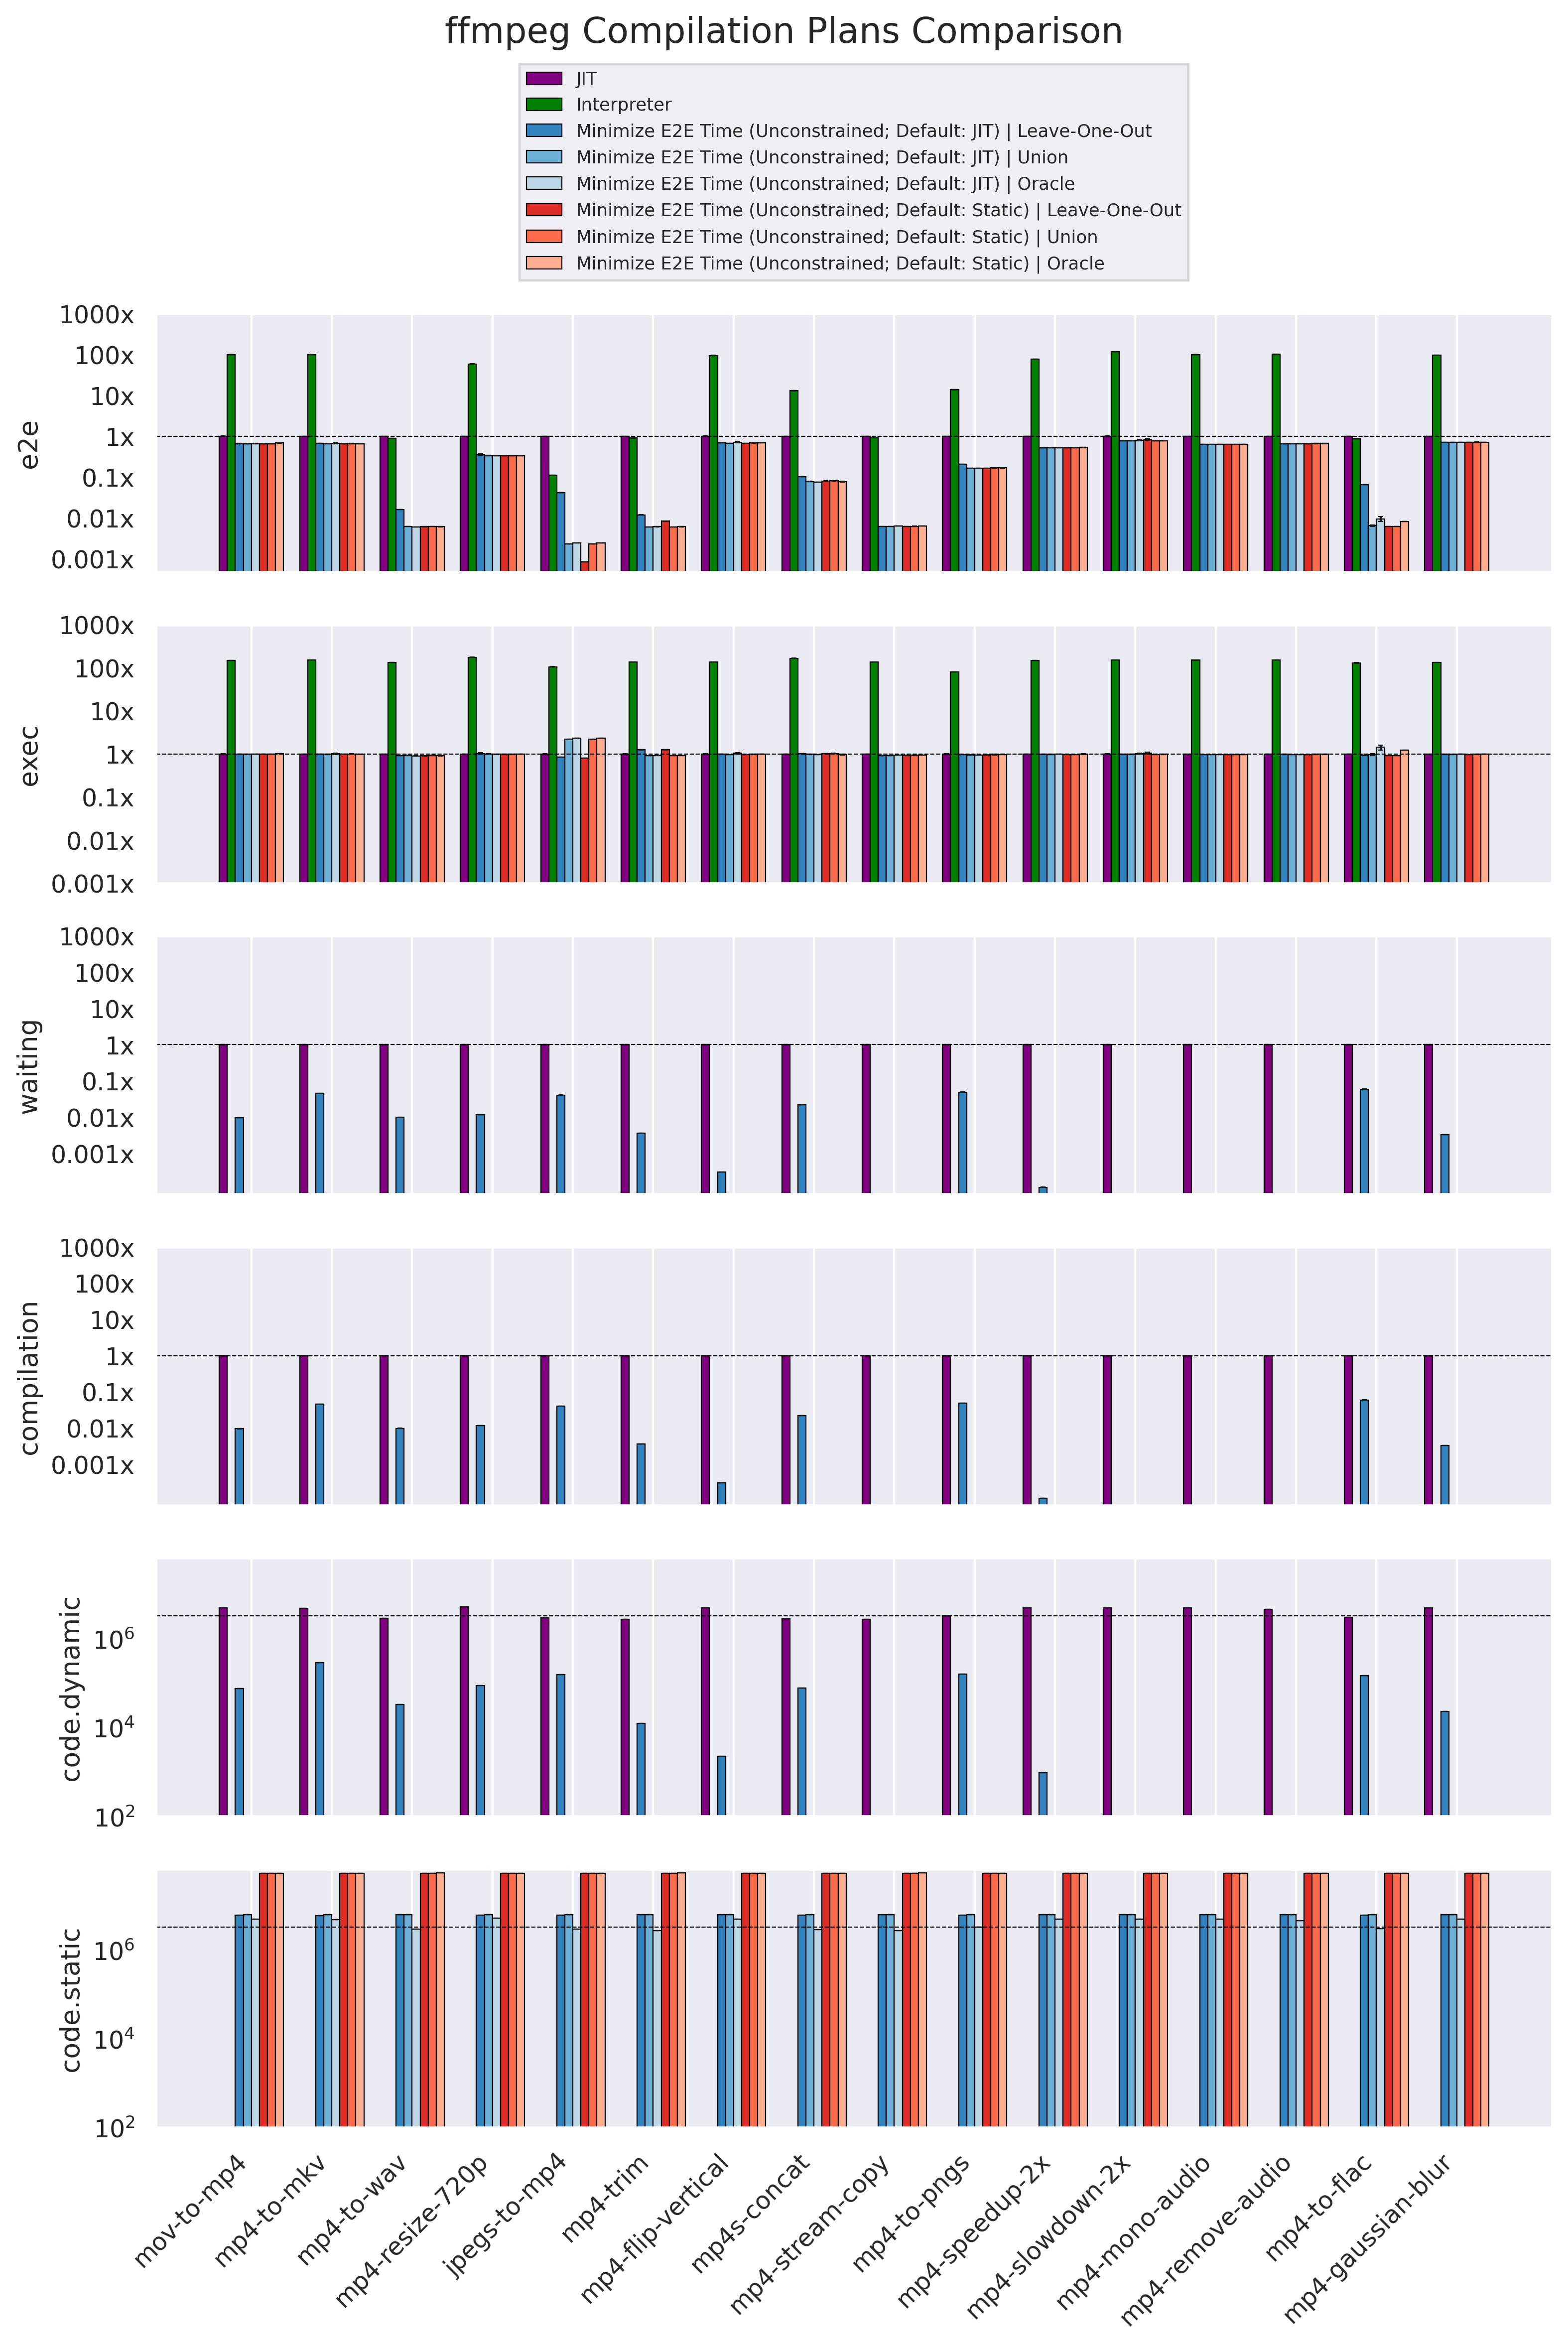

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from bokeh import palettes

plans_titles = df["config"].unique().tolist()
workloads_names = df["workload"].unique().tolist()

metrics = [
    "e2e",
    "exec",
    "waiting",
    "compilation",
    "code.dynamic",
    "code.static",
]

relative_metrics = {"e2e", "exec", "waiting", "compilation"}
code_metrics = {"code.dynamic", "code.static"}


def get_metric_values(workload, config, metric):
    value = df.loc[
        (df["workload"] == workload) & (df["config"] == config),
        metric
    ].iloc[0]
    arr = np.asarray(value, dtype=float)
    if arr.ndim == 0:
        arr = np.array([float(arr)])
    return arr


def normalize_against_baseline(values, baseline_values):
    baseline_mean = np.mean(baseline_values)
    if baseline_mean == 0:
        return values
    return values / baseline_mean


plan_colors = ["purple", "green"]
plan_colors.extend(palettes.Blues5[1:-1])
plan_colors.extend(palettes.Reds5[1:-1])

if len(plan_colors) < len(plans_titles):
    extra = sns.color_palette("tab20", len(plans_titles) - len(plan_colors))
    plan_colors.extend(extra)

sns.set_theme()

n_plans = len(plans_titles)
xs = np.arange(len(workloads_names))
bar_width = min(0.8 / max(n_plans, 1), 0.12)
offsets = (np.arange(n_plans) - (n_plans - 1) / 2) * bar_width

fig, axs = plt.subplots(
    len(metrics), 1,
    figsize=(10, len(metrics) * 2.5),
    dpi=320,
    sharex=True,
)

binary_size = Path(benchmark.binary).stat().st_size

for metric_idx, metric in enumerate(metrics):
    ax = axs[metric_idx]

    baseline = [
        get_metric_values(wl, plans_titles[0], metric)
        for wl in workloads_names
    ]

    for plan_bar_idx, plan_title in enumerate(plans_titles):
        ys = [
            get_metric_values(wl, plan_title, metric)
            for wl in workloads_names
        ]

        if metric in relative_metrics:
            ys = [
                normalize_against_baseline(y, b)
                for y, b in zip(ys, baseline)
            ]

        means = [np.mean(v) for v in ys]
        stds = [np.std(v) for v in ys]
        positions = xs + offsets[plan_bar_idx]

        ax.bar(
            positions,
            means,
            yerr=stds,
            error_kw={"elinewidth": 1, "capsize": 1.2, "capthick": 0.5},
            width=bar_width,
            label=plan_title,
            color=plan_colors[plan_bar_idx],
            edgecolor="black",
            linewidth=0.5,
        )

    ax.set_ylabel(metric)
    ax.grid(axis="y")
    ax.set_xticks([])

    if metric in code_metrics:
        ax.set_yscale("log")
        ax.set_ylim(100, binary_size)
        ax.axhline(binary_size * 0.05, color="black", linestyle="--", linewidth=0.5)
    elif metric in relative_metrics:
        # draw a horz line at 1
        ax.axhline(1, color="black", linestyle="--", linewidth=0.5)
        ax.set_yscale("log")
        ax.set_yticks([0.001, 0.01, 0.1, 1, 10, 100, 1000])
        ax.set_yticklabels(["0.001x", "0.01x", "0.1x", "1x", "10x", "100x", "1000x"])

axs[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 2),
    ncol=1,
    fancybox=False,
    shadow=False,
    frameon=True,
    fontsize=8,
)
axs[-1].set_xticks(xs, workloads_names, rotation=45, ha="right")

fig.suptitle(f"{benchmark.name} Compilation Plans Comparison", fontsize=16)
plt.tight_layout()
plt.savefig("./out/comparison.pdf", dpi=320)
plt.show()

In [4]:
benchmark = ffmpeg

In [5]:
# get the matrix of waiting times using profile = Profile(Path(f'/tmp/async/{wl.name}.{wl.name}'))
# then get the min and max of waiting
matrix = []
for wl in benchmark.workloads:
    row = []
    for other_wl in benchmark.workloads:
        path = Path(f'/tmp/async/{wl.name}.{other_wl.name}')
        profile = Profile(path)
        metric_list = profile.waiting
        assert len(metric_list) == 3, f'Expected 3 waiting times for {wl.name} trained on {other_wl.name}, but got {len(metric_list)}'
        metric = np.average(metric_list)
        row.append(metric)
    matrix.append(row)
    
matrix = np.array(matrix)

# for each benchmark give the best (except itself) and worst waiting time 
worsts = []
bests = []
avgs = []
for i, wl in enumerate(benchmark.workloads):
    best_time = float('inf')
    worst_time = float('-inf')
    best_wl = None
    worst_wl = None
    l = []
    for j, other_wl in enumerate(benchmark.workloads):
        if i == j:
            continue
        time = matrix[i][j]
        if time < best_time:
            best_time = time
            best_wl = other_wl.name
        if time > worst_time:
            worst_time = time
            worst_wl = other_wl.name
        l.append(time)
    avg = np.average(l)
    print(f'{wl.name}: Best waiting time {best_time:.2f} trained on {best_wl}, Worst waiting time {worst_time:.2f} trained on {worst_wl}')
    bests.append(best_wl)
    worsts.append(worst_wl)
    avgs.append(avg)
    

mov-to-mp4: Best waiting time 13569705939.00 trained on mp4-mono-audio, Worst waiting time 28258329757.67 trained on mp4-to-flac
mp4-to-mkv: Best waiting time 15116981461.67 trained on mp4-mono-audio, Worst waiting time 28144475823.33 trained on mp4-trim
mp4-to-wav: Best waiting time 7486965944.00 trained on mp4-to-flac, Worst waiting time 15338883516.00 trained on jpegs-to-mp4
mp4-resize-720p: Best waiting time 14415080294.67 trained on mp4-flip-vertical, Worst waiting time 29478679377.00 trained on mp4-to-flac
jpegs-to-mp4: Best waiting time 9159795755.67 trained on mp4-remove-audio, Worst waiting time 19598188889.00 trained on mp4-to-wav
mp4-trim: Best waiting time 6667245765.33 trained on mp4-stream-copy, Worst waiting time 14779826076.00 trained on jpegs-to-mp4
mp4-flip-vertical: Best waiting time 13150675481.67 trained on mp4-mono-audio, Worst waiting time 28309789104.00 trained on mp4-to-flac
mp4s-concat: Best waiting time 7026711810.67 trained on mp4-stream-copy, Worst waiting 

In [6]:
modes = [
    'jit', 
    'async.static.worst',
    'async.static.best',
    'async.static.avg',
    'async.dynamic.leave_one_out', 
    'async.dynamic.union', 
    'async.static.oracle'     
    ]
modes_names = {
    'jit': 'JIT',
    'async.dynamic.leave_one_out': 'Async | Dynamic | Leave-One-Out',
    'async.dynamic.union': 'Async | Dynamic | Union',
    'async.static.oracle': 'Async | Static | Oracle',
    'async.static.worst': 'Async | Static | Worst',
    'async.static.best': 'Async | Static | Best',
    'async.static.avg': 'Async | Static | Average'
}


data = []
for i, wl in enumerate(benchmark.workloads):
    for mode in modes:
        if mode == 'jit':
            values = Profile(profiles_root(benchmark.binary, wl.name, 'jit')).waiting
        elif mode == 'async.dynamic.leave_one_out':
            values = Profile(profiles_root(benchmark.binary, wl.name, 'async') / 'leave_one_out').waiting
        elif mode == 'async.dynamic.union':
            values = Profile(profiles_root(benchmark.binary, wl.name, 'async') / 'union').waiting
        elif mode == 'async.static.oracle':
            values = Profile(Path(f'/tmp/async/{wl.name}.{wl.name}')).waiting
        elif mode == 'async.static.worst':
            values = Profile(Path(f'/tmp/async/{wl.name}.{worsts[i]}')).waiting
        elif mode == 'async.static.best':
            values = Profile(Path(f'/tmp/async/{wl.name}.{bests[i]}')).waiting
        elif mode == 'async.static.avg':
            values = [avgs[i]]

        for value in values:
            # make it in s
            value = value / 1e9
            data.append([wl.name, mode, value])
            
    

df = pd.DataFrame(data, columns=['workload', 'mode', 'waiting'])
df['mode'] = df['mode'].map(modes_names)
df

,workload,mode,waiting
0,mov-to-mp4,JIT,38.832707
1,mov-to-mp4,JIT,38.602674
2,mov-to-mp4,JIT,38.827942
3,mov-to-mp4,JIT,38.804710
4,mov-to-mp4,JIT,38.730438
...,...,...,...
624,mp4-gaussian-blur,Async | Dynamic | Union,19.294731
625,mp4-gaussian-blur,Async | Dynamic | Union,19.118089
626,mp4-gaussian-blur,Async | Static | Oracle,13.224826
627,mp4-gaussian-blur,Async | Static | Oracle,13.226946


/tmp/ipykernel_1328414/3875285878.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='workload', y='waiting', hue='mode', data=df, ci=None)


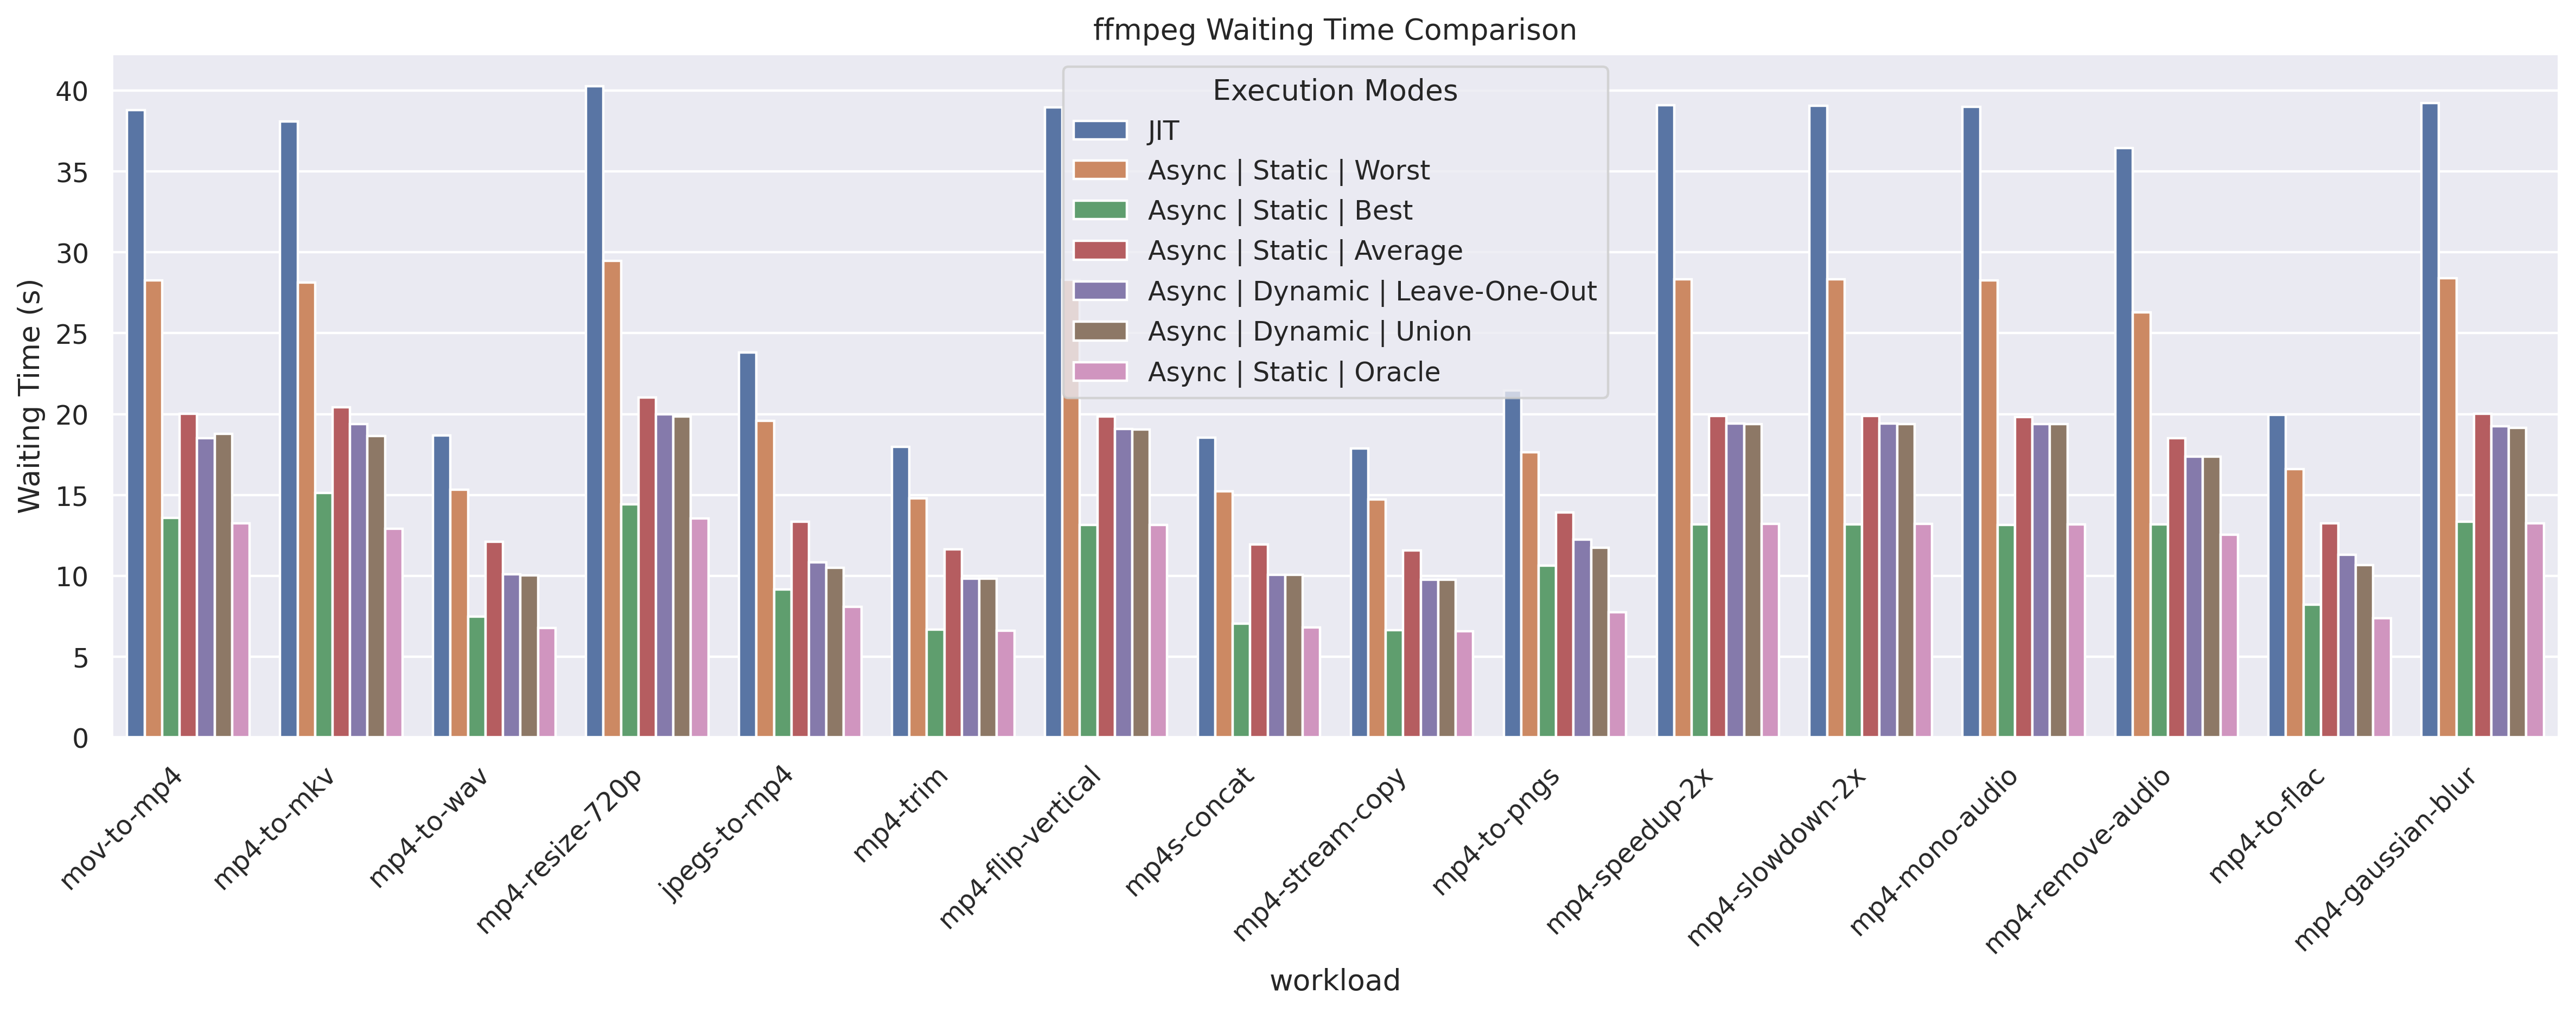

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# plot for each workload, the waiting time for each mode as a bar chart with error bars
sns.set_theme()
plt.figure(figsize=(15, 6), dpi=320)
# sns.barplot(x='workload', y='waiting', hue='mode', data=df, ci='sd')
# hide error bars for now
sns.barplot(x='workload', y='waiting', hue='mode', data=df, ci=None)

plt.ylabel('Waiting Time (s)')
plt.xticks(rotation=45, ha='right')
# show ys as seconds (they are ns now)

plt.title(f'{benchmark.name} Waiting Time Comparison')
plt.legend(title='Execution Modes')
plt.tight_layout()
# plt.savefig(f'/tmp/truejit/evaluation/compilation-plan/out/waiting_time_comparison.pdf', dpi=320)
plt.show()

In [ ]:
def get_name(plan):
    return {
        'min_e2e.unconstrained.default_static': 'Minimize End-to-End Time (Unconstrained; Default: AOT)',
        'min_e2e.unconstrained.default_jit': 'Minimize End-to-End Time (Unconstrained; Default: JIT)',
        # 'min_e2e.file_size_lt_5percent': r'Minimize End-to-End Time (Constrained: Static Code Size $<$ 5\% of Binary Size; Default: JIT)',
    }[plan]

In [ ]:
def get_profiles_matrix(benchmark, plan):
    profiles = []
    for wl_validation in benchmark.workloads:
        wl_profiles = []
        # print(f'[validation] {wl_validation.name}')
        for wl_trained in benchmark.workloads:
            # print(f'[trained] {wl_trained.name}')
            path = profiles_root(benchmark.binary, wl_validation.name, plan) / f'trained_on_{wl_trained.name}'
            # print(path)
            if not path.exists():
                raise ValueError(f'No profile found for {plan} on {wl_validation.name} trained on {wl_trained.name}')
            else:
                wl_profiles.append(Profile(path))
        profiles.append(wl_profiles)
    return profiles


plan = 'min_e2e.unconstrained.default_jit'
# plan = 'min_e2e.file_size_lt_5percent'
profiles_matrix = get_profiles_matrix(ffmpeg, plan)

In [ ]:
benchmark = ffmpeg
matrices = []
plans = [
    'min_e2e.unconstrained.default_static',
    'min_e2e.unconstrained.default_jit',
]
for plan in plans:
    profiles_matrix = get_profiles_matrix(benchmark, plan)

    matrix = np.zeros((len(benchmark.workloads), len(benchmark.workloads)))
    for i, wl_validation in enumerate(benchmark.workloads):
        print(f'[{wl_validation.name}]')
        for j, wl_trained in enumerate(benchmark.workloads):
            # metric = profiles_matrix[i][j]['exec'].sum()
            metric = np.average(profiles_matrix[i][j].e2e)
            matrix[i, j] = metric

        # print row
        print('before normalization:')
        print(*matrix[i], sep='\t')
        baseline = matrix[i, i]
        matrix[i, :] = baseline / matrix[i, :]
        print('after normalization:')
        print(*matrix[i], sep='\t')
        print()

    matrices.append(matrix)

In [ ]:
# mcolors
import matplotlib.colors as mcolors
import seaborn as sns

sns.set_theme()
fig, axes = plt.subplots(2, 1, figsize=(10, 12), dpi=320, sharex=True)

# find min and max in both matrice
min_val, max_val = np.min(matrices[0]), np.max(matrices[0])
for matrix in matrices:
    min_val = min(min_val, np.min(matrix))
    max_val = max(max_val, np.max(matrix))

for matrix_idx, matrix in enumerate(matrices):
    # diverging normalization centered at 1
    norm = mcolors.TwoSlopeNorm(
        vmin=min_val,
        vcenter=1,
        vmax=max_val
    )

    # red -> white -> green colormap
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "red_white_green",
        ["darkred", "white", "darkgreen"]
    )

    sns.heatmap(
        matrix,
        cmap=cmap,
        annot=True,
        fmt=".2f",
        ax=axes[matrix_idx],
        linewidths=1,
        linecolor='white',
        norm=norm,
        cbar=False
    )

    # distinguish visaully the diagonal
    for i in range(len(benchmark.workloads)):
        for j in range(len(benchmark.workloads)):
            if i == j:
                axes[matrix_idx].add_patch(plt.Rectangle((i, j), 1, 1, edgecolor='navy', facecolor='gold', linewidth=1))

    axes[matrix_idx].set_xticklabels([wl.name for wl in benchmark.workloads], rotation=45, ha='right')
    axes[matrix_idx].set_yticklabels([wl.name for wl in benchmark.workloads], rotation=0, va='center')

    axes[matrix_idx].set_ylabel('Validation Benchmark')

    axes[matrix_idx].set_title(f'{get_name(plans[matrix_idx])}')

axes[-1].set_xlabel('Trained On')

plt.tight_layout()

# to pdf
# plt.savefig(f'/tmp/truejit/evaluation/compilation-plan/out/matrix_{plan}.pdf', dpi=320)

plt.show()

In [6]:
import numpy as np

benchmark = ffmpeg
matrix = []
for wl in benchmark.workloads:
    row = []
    for other_wl in benchmark.workloads:
        # path = Path(f'/tmp/async/{wl.name}.{other_wl.name}')
        # path = PROJECT_ROOT /'profiles' / benchmark.name / wl.name / 'async/static' / other_wl.name
        path = profiles_root(benchmark.binary, wl.name, 'async/static') / other_wl.name
        profile = Profile(path)
        metric_list = profile.waiting
        assert len(metric_list) == 3, f'Expected 3 waiting times for {wl.name} trained on {other_wl.name}, but got {len(metric_list)}'
        metric = np.average(metric_list)
        # metric = metric_list[1]
        row.append(metric)
        
    profile = Profile(profiles_root(benchmark.binary, wl.name, 'jit'))
    metric_list = profile.waiting
    metric = np.average(metric_list)
    row.append(metric)
    
    matrix.append(row)
matrix = np.array(matrix)
print(matrix)

# make values in each row relative to the diagonal
for i in range(len(matrix)):
    baseline = matrix[i, i]
    matrix[i, :] = baseline / matrix[i, :]
print(matrix)

[[1.32474149e+10 1.59017994e+10 2.77988312e+10 1.37098146e+10
  1.95253489e+10 2.80528490e+10 1.35789015e+10 2.81340456e+10
  2.80855340e+10 2.75069279e+10 1.36102967e+10 1.35730249e+10
  1.35697059e+10 1.53288741e+10 2.82583298e+10 1.36138044e+10
  3.88011625e+10]
 [1.55729478e+10 1.29223327e+10 2.68751815e+10 1.52786943e+10
  1.97604097e+10 2.81444758e+10 1.51213108e+10 2.81379599e+10
  2.80905862e+10 2.62369526e+10 1.51480549e+10 1.51602393e+10
  1.51169815e+10 1.51847964e+10 2.72122473e+10 1.51764171e+10
  3.80955557e+10]
 [1.39064029e+10 1.32855796e+10 6.75867483e+09 1.37772266e+10
  1.53388835e+10 8.96144729e+09 1.36938241e+10 9.10449146e+09
  8.93144739e+09 8.63478058e+09 1.37284540e+10 1.37129947e+10
  1.36563005e+10 1.36384295e+10 7.48696594e+09 1.37326788e+10
  1.86890147e+10]
 [1.49543494e+10 1.68563179e+10 2.90272082e+10 1.35310504e+10
  2.10210637e+10 2.91922297e+10 1.44150803e+10 2.92933506e+10
  2.91735147e+10 2.76652929e+10 1.44464373e+10 1.44461756e+10
  1.44266233e+10

min_val: 0.335964160757066, max_val: 1.0020780184112832


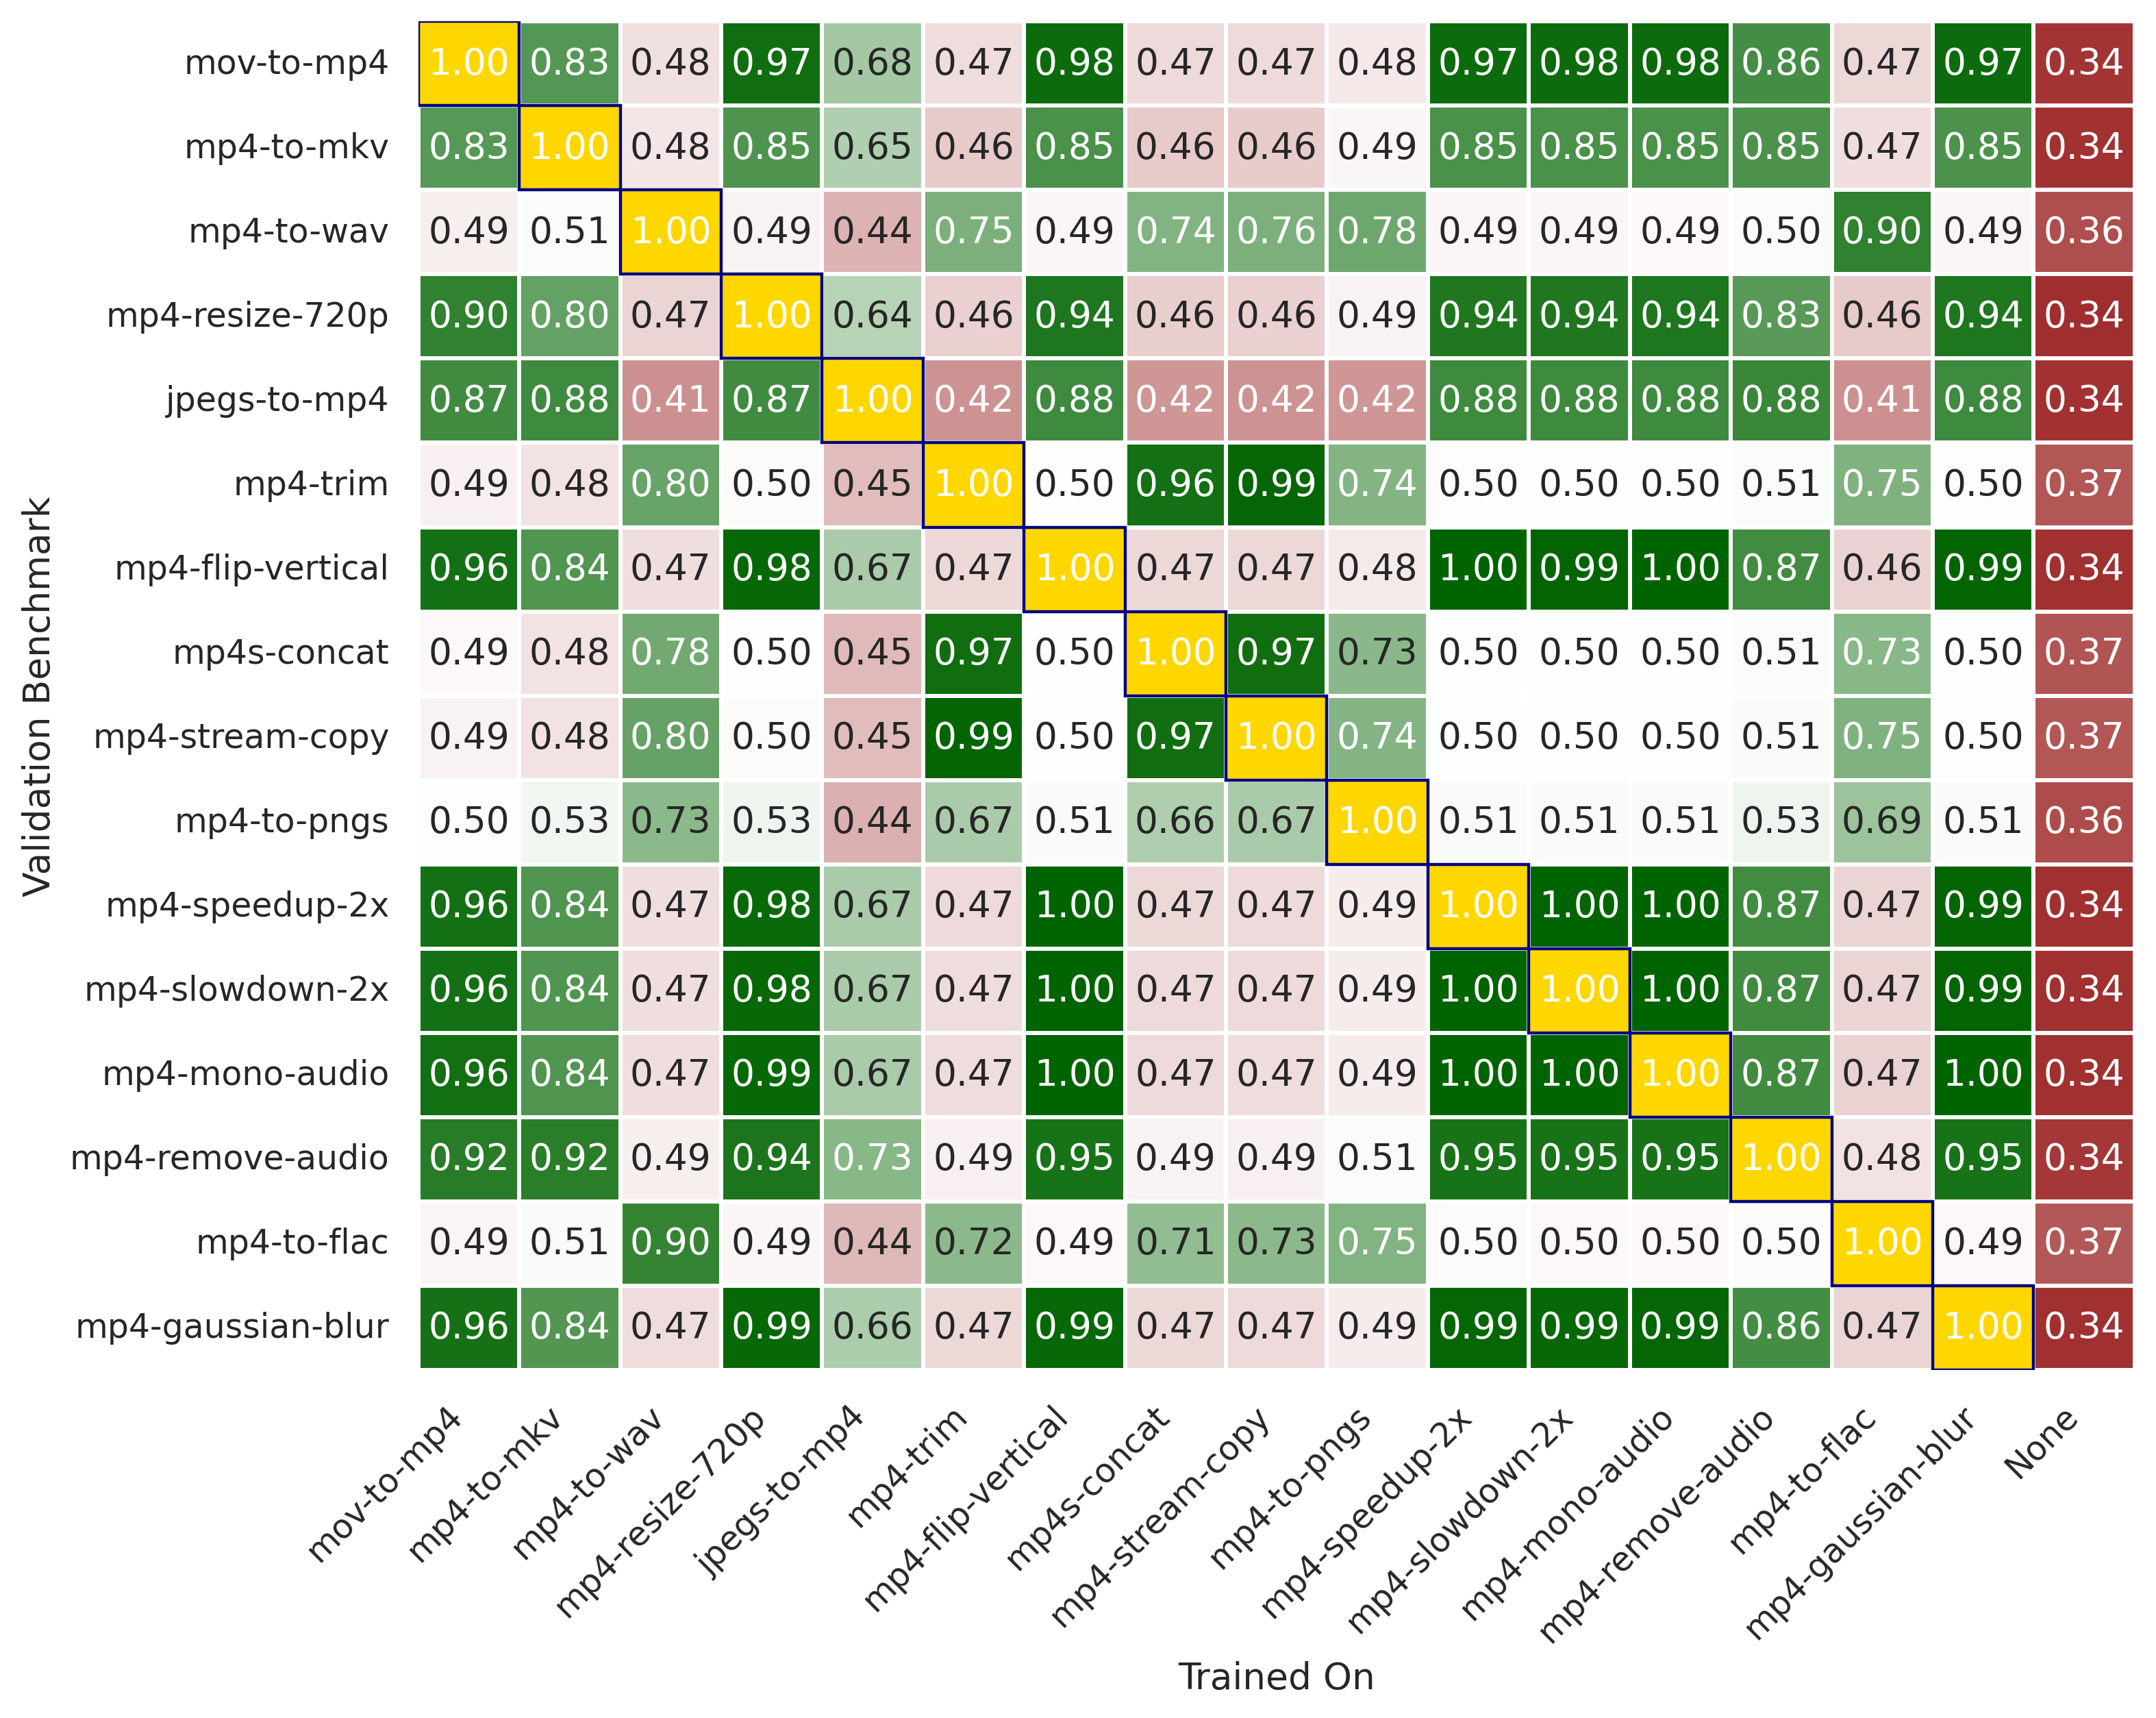

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

sns.set_theme()

fig, ax = plt.subplots(figsize=(10, 8), dpi=320)

# compute min/max for this single matrix
min_val, max_val = np.min(matrix), np.max(matrix)
print(f'min_val: {min_val}, max_val: {max_val}')

# normalization centered at 1
norm = mcolors.TwoSlopeNorm(
    vmin=.3,
    vcenter=.5,
    vmax=1
)

# red -> white -> green colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "red_white_green",
    ["darkred", "white", "darkgreen"]
)

sns.heatmap(
    matrix,
    cmap=cmap,
    annot=True,
    fmt=".2f",
    ax=ax,
    linewidths=1,
    linecolor='white',
    norm=norm,
    cbar=False
)

# highlight diagonal
for i in range(len(benchmark.workloads)):
    ax.add_patch(
        plt.Rectangle(
            (i, i), 1, 1,
            edgecolor='navy',
            facecolor='gold',
            linewidth=1
        )
    )

ax.set_xticklabels(
    [wl.name for wl in benchmark.workloads] + ['None'],
    rotation=45,
    ha='right'
)
ax.set_yticklabels(
    [wl.name for wl in benchmark.workloads],
    rotation=0,
    va='center'
)

ax.set_ylabel('Validation Benchmark')
ax.set_xlabel('Trained On')

# optional title (if you still want it)
# ax.set_title(get_name(plan))

plt.tight_layout()
plt.show()

In [ ]:
benchmark = ffmpeg
base_workload = 'mp4-flip-vertical'
for wl in benchmark.workloads:
    print(f'trained_on_{wl.name}')
    plan_path = plans_root(benchmark.binary, base_workload,
                           'min_e2e.unconstrained.default_jit') / f'trained_on_{wl.name}.json'
    print(f'plan_path: {plan_path}')
    plan = plan_json_to_df(plan_path)
    print(plan['mode'].value_counts())
    print()


In [ ]:
benchmark = gcc_loops
generate_static_info(benchmark.binary)

In [ ]:
static_info = get_static_info(benchmark.binary)
base_profile = pd.read_csv(profiles_root(benchmark.binary, benchmark.workloads[0].name) / 'base.csv')
plan = plan_json_to_df(plans_root(benchmark.binary, benchmark.workloads[0].name, 'min_e2e') / 'oracle.json')
df = pd.merge(base_profile, plan, on='id', how='outer')
df

In [ ]:
class PlanEvaluation:
    def __init__(self, static_info, base_profile, plan):
        e2e = 0
        exec = 0
        waiting = 0
        compilation = 0
        dynamic_code_size = 0
        static_code_size = 0

        # merge on both ('id', 'name')
        df = pd.merge(static_info, base_profile, on=['id', 'name', 'size.bytecode', 'size.static'], how='outer')

        df = pd.merge(df, plan, on='id', how='outer')
        df.drop('name', axis=1, inplace=True)
        df.fillna(0, inplace=True)
        # print(df.to_string())

        # iterate the rows of df
        for i, row in df.iterrows():
            mode = row['mode']
            if mode == 'interpret':
                e2e += row['exec.interp']
                exec += row['exec.interp']
                waiting += 0
                compilation += 0
                dynamic_code_size += 0
                static_code_size += 0
            elif mode == 'jit':
                e2e += row['exec.jit'] + row['compilation.jit']
                exec += row['exec.jit']
                waiting += row['compilation.jit']
                compilation += row['compilation.jit']
                dynamic_code_size += row['size.dynamic.jit']
                static_code_size += 0
            elif mode == 'static':
                e2e += row['exec.jit']  # like jit without compilation/waiting
                exec += row['exec.jit']  # like jit
                waiting += 0
                compilation += 0
                dynamic_code_size += row['size.dynamic.jit']  # also add the dynamic code
                static_code_size += row['size.static']
            elif mode == 'async':
                e2e += row['exec.jit'] + .5 * row[
                    'compilation.jit']  # assume async compilation happens in parallel with execution, so we only add half of the compilation time to e2e
                exec += row['exec.jit']
                waiting += .5 * row[
                    'compilation.jit']  # assume async compilation happens in parallel with execution, so we only add half of the compilation time to waiting
                compilation += row['compilation.jit']
                dynamic_code_size += row['size.dynamic.jit']
                static_code_size += 0
            elif mode == 'specialize':
                e2e += row['exec.spec'] + row['compilation.spec']
                exec += row['exec.spec']
                waiting += row['compilation.spec']
                compilation += row['compilation.spec']
                dynamic_code_size += row['size.dynamic.spec']
                static_code_size += 0
            else:
                raise ValueError(f'Unknown mode: {mode}')

        plan_modes = plan['mode'].value_counts().to_dict()
        self.jit = plan_modes.get('jit', 0)
        self.interpret = plan_modes.get('interpret', 0)
        self.async_compilation = plan_modes.get('async', 0)
        self.specialize = plan_modes.get('specialize', 0)
        self.static = plan_modes.get('static', 0)

        self.e2e = e2e
        self.exec = exec
        self.waiting = waiting
        self.compilation = compilation
        self.dynamic_code_size = dynamic_code_size
        self.static_code_size = static_code_size

    def __str__(self):
        return json.dumps({
            'jit': self.jit,
            'interpret': self.interpret,
            'async_compilation': self.async_compilation,
            'specialize': self.specialize,
            'static': self.static,
            'e2e': self.e2e,
            'exec': self.exec,
            'waiting': self.waiting,
            'compilation': self.compilation,
            'dynamic_code_size': self.dynamic_code_size,
            'static_code_size': self.static_code_size,
        }, indent=2)


PlanEvaluation(static_info, base_profile, plan)

In [ ]:
class Planning:
    def __init__(self, goal, constraints, default):
        self.goal = goal
        self.constraints = constraints
        self.default = default

    def get_plan(self, static_info, base_profile):
        all_ids = static_info['id'].tolist()
        if self.goal is None:
            return pd.DataFrame({'id': all_ids, 'mode': [self.default] * len(all_ids)})
        solver = Solver(base_profile)
        solver.solve(self.goal, self.constraints, timeout=10)
        plan = solver.plan
        unplanned_ids = set(all_ids) - set(plan['id'].tolist())
        defaults = pd.DataFrame({'id': list(unplanned_ids), 'mode': [self.default] * len(unplanned_ids)})
        return pd.concat([plan, defaults])

In [ ]:
plans = []
plans.append(('Interpreter', Planning(None, None, 'interpret')))
plans.append(('JIT', Planning(None, None, 'jit')))
plans.append(('AOT', Planning(None, None, 'static')))
plans.append(('Code = 0',
              Planning(EndToEndTime(),
                       [Constraint(StaticCodeSize(), upper_bound=0), Constraint(DynamicCodeSize(), upper_bound=0)],
                       'interpret')))
plans.append((r'Code $< 10\,\mathrm{KB}$',
              Planning(EndToEndTime(), [Constraint(StaticCodeSize(), upper_bound=10_000),
                                        Constraint(DynamicCodeSize(), upper_bound=10_000)], 'interpret')))

plans.append((r'Code $< 200\,\mathrm{KB}$',
              Planning(EndToEndTime(), [Constraint(StaticCodeSize(), upper_bound=100_000),
                                        Constraint(DynamicCodeSize(), upper_bound=100_000)], 'interpret')))

# plans.append(('Code < 1MB (Default: interpret)',
#               Planning(EndToEndTime(), [Constraint(DynamicCodeSize(), upper_bound=1_000_000)], 'interpret')))
plans.append(('Unbounded Code',
              Planning(EndToEndTime(), [], 'static')))

evaluations = []
for plan_title, planning in plans:
    print(plan_title)
    plan = planning.get_plan(static_info, base_profile)
    evaluation = PlanEvaluation(static_info, base_profile, plan)
    print(evaluation)
    evaluations.append(evaluation)
    print("---------")

In [ ]:
from bokeh.palettes import *

colors = [
    'cyan',
    'green',
    'purple',
]
for i in range(len(plans[3:])):
    colors.append('blue')

In [ ]:
code_sizes = [e.static_code_size + e.dynamic_code_size for e in evaluations]
e2es = [e.e2e for e in evaluations]
plans_titles = [plan_title for plan_title, _ in plans]

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif"],
})

In [ ]:


fig, ax = plt.subplots(figsize=(4, 2.2), dpi=320)

linewidth = 0.25
ax.scatter(code_sizes[0], e2es[0], color=colors[0], label=plans_titles[0], alpha=1, edgecolor='black',
           linewidth=linewidth, marker='X', s=100)
ax.scatter(code_sizes[1], e2es[1], color=colors[1], label=plans_titles[1], alpha=1, edgecolor='black',
           linewidth=linewidth, marker='X', s=100)
ax.scatter(code_sizes[2], e2es[2], color=colors[2], label=plans_titles[2], alpha=1, edgecolor='black',
           linewidth=linewidth, marker='X', s=100)

ax.scatter(code_sizes[3:], e2es[3:], color=colors[3:], label='CAPER', alpha=1, edgecolor='black', linewidth=linewidth,
           marker='o', s=50)

LEFT_PADDING = 50000
for i in range(len(plans[3:])):
    eval = evaluations[3 + i]
    text = plans_titles[3 + i]
    ax.text(code_sizes[3 + i] + LEFT_PADDING, e2es[3 + i] * 1.9, text, fontsize=9, ha='left', va='top', color='black',
            bbox=dict(facecolor='gold', edgecolor='crimson', linewidth=linewidth, boxstyle='round,pad=0.1'))
    text = ''
    if eval.interpret:
        text += f'Interpreted: {eval.interpret}\n'
    if eval.jit:
        text += f'JIT: {eval.jit}\n'
    if eval.specialize:
        text += f'Specialized: {eval.specialize}\n'
    if eval.async_compilation:
        text += f'Async: {eval.async_compilation}\n'
    if eval.static:
        text += f'Static: {eval.static}\n'
    text = text.strip()
    ax.text(code_sizes[3 + i] + LEFT_PADDING, e2es[3 + i] * 1, text, fontsize=9, ha='left', va='top', color='black',
            bbox=dict(facecolor='lightblue', edgecolor='blue', linewidth=linewidth, boxstyle='round,pad=0.1'))

# make y log
ax.set_ylim(5e8, 2e12)
ax.set_yscale('log')
ax.set_yticks([1e9, 1e10, 1e11, 1e12])
ax.set_yticklabels(['1', '10', '100', '1000'])

# set x lim to 1.5MB
ax.set_xlim(-50000, 1400000)
# 0, 200k, 400k, 600k, ..., 1MB
ax.set_xticks([0, 200000, 400000, 600000, 800000, 1000000, 1200000, 1400000])
ax.set_xticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1', '1.2', '1.4'])

ax.tick_params(axis='both', pad=1)

ax.set_xlabel('Code Size (MB)', labelpad=0)
ax.set_ylabel('End-to-End Time (s)', labelpad=0)
# ax.set_title(f'{benchmark.name} Compilation Plans Comparison')
ax.legend()

# make it tight
plt.tight_layout(pad=0)

# to pdf
plt.savefig(f'/tmp/truejit/evaluation/compilation-plan/out/motivation.pdf', bbox_inches='tight', dpi=320, format='pdf')

plt.show()

In [ ]:
benchmark = gcc_loops
static_info = get_static_info(benchmark.binary)
base_profile = pd.read_csv(profiles_root(benchmark.binary, benchmark.workloads[0].name) / 'base.csv')
plan = plan_json_to_df(plans_root(benchmark.binary, benchmark.workloads[0].name, 'min_e2e') / 'oracle.json')
df = pd.merge(base_profile, plan, on='id', how='outer')
df

In [ ]:
df = base_profile[['id', 'start.jit']]
df = pd.merge(df, plan, on='id', how='left')
# sort by 'start.jit'
df = df.sort_values('start.jit')
df

In [ ]:
for i, row in df.iterrows():
    print(f'[{i} id={row['id']} mode={row["mode"]}]')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

num = len(df)
columns = 100
rows = num // columns + (1 if num % columns != 0 else 0)
print(f'num={num} columns={columns} rows={rows}')

get_cell = lambda i: (i % columns, i // columns)
get_color = lambda mode: {
    'interpret': 'orange',
    'jit': 'crimson',
    'static': 'magenta',
    'specialize': 'gold',
    'async': 'cyan',
}[mode]

cell_width = .2
cell_height = .5

fig, ax = plt.subplots(figsize=(cell_width * columns, cell_height * rows), dpi=320)
ax.set_aspect('equal')

for i, row in df.iterrows():
    x, y = get_cell(i)
    x *= cell_width
    y *= cell_height
    color = get_color(row['mode'])
    ax.add_patch(plt.Rectangle((x, y), cell_width, cell_height, facecolor=color, edgecolor='white', linewidth=1))
    # ax.text(x + cell_width / 2, y + cell_height / 2, str(row['id']), ha='center', va='center')

# x-axis labels
for i in range(columns):
    val = i + 1
    if val % 10 == 0:
        ax.text((i + .5) * cell_width, (0 - .5) * cell_height, str(val), ha='center', va='center_baseline')

# y-axis labels
for i in range(rows):
    val = i * columns
    ax.text((0 - .5) * cell_width, (i + .5) * cell_height, str(val), ha='right', va='center')

ax.axis('off')

ax.set_xlim(0, columns * cell_width)
ax.set_ylim(0, rows * cell_height)

In [ ]:
benchmark = ffmpeg

plan_mode = 'min_e2e'
wl = 'mp4-to-pngs'
before, after = 'oracle', 'trained_on_mov-to-mp4'

In [ ]:
df = pd.merge(df, plans, on='id', how='left')
print(df['exec.diff'].sum())
df = df[[]]

In [ ]:
def plan_diff(binary, wl, plan_mode, before, after):
    before_plan = plan_json_to_df(plans_root(binary, wl, plan_mode) / f'{before}.json')
    # print(before_plan['mode'].value_counts())
    after_plan = plan_json_to_df(plans_root(binary, wl, plan_mode) / f'{after}.json')
    print(after_plan['mode'].value_counts())
    plans = pd.merge(before_plan, after_plan, on='id', how='outer', suffixes=['.before', '.after'])

    before_profile = get_profile(profiles_root(binary, wl, plan_mode) / before)
    after_profile = get_profile(profiles_root(binary, wl, plan_mode) / after)

    e2e_diff = Profile(profiles_root(binary, wl, plan_mode) / after).e2e - Profile(
        profiles_root(binary, wl, plan_mode) / before).e2e
    print(f'{e2e_diff} e2e_diff')
    e2e_diff = Profile(profiles_root(binary, wl, plan_mode) / after).e2e / Profile(
        profiles_root(binary, wl, plan_mode) / before).e2e
    print(f'{e2e_diff} e2e_diff_ratio')

    merged_profile = pd.merge(before_profile, after_profile, on='id', how='outer', suffixes=['.before', '.after'])
    metrics = ['freq', 'exec', 'compilation', 'size.dynamic']

    df = pd.DataFrame({'id': merged_profile['id']})
    for metric in metrics:
        df[f'{metric}.diff'] = merged_profile[f'{metric}.after'] - merged_profile[f'{metric}.before']
        if (df[f'{metric}.diff'] == 0).all():
            df = df.drop(f'{metric}.diff', axis=1)

    df = pd.merge(plans, df, on='id', how='right')
    return df


before = 'trained_on_mp4-to-pngs'
before = 'trained_on_mp4-gaussian-blur'
before = 'trained_on_mp4-to-wav'
dfs = []
for w in benchmark.workloads:
    after = f'trained_on_{w.name}'
    print(after)
    plan_mode = 'min_e2e'
    plan_mode = 'min_e2e.default_jit'
    # plan_mode = 'min_e2e.file_size_lt_5percent'
    df = plan_diff(benchmark.binary, w.name, plan_mode, before, after)
    # sort df by exec diff
    if 'exec.diff' in df:
        df = df.sort_values('exec.diff')
    # print(df.head().to_string(index=False))

    dfs.append(df)

    # print(sum(df['exec.diff']))
    print()
    print()
    print()

# mode
# jit          25798
# static        1688
# interpret        4
# Name: count, dtype: int64

In [ ]:
dfs[0]

In [ ]:
import pandas as pd
import numpy as np
import sys

sys.path.append('/tmp/truejit/evaluation/compilation-plan')
from profiling import *
from utils import *

benchmark = ffmpeg
workload_name = 'mov-to-mp4'
history = get_history(benchmark.binary, workload_name)
history = pd.DataFrame(history, columns=['id'])


def dry_run(plan, profile, history):
    df = pd.merge(profile, plan, on='id', how='left')
    df = pd.merge(history, df, on='id', how='left')

    e2e = 0
    for i, row in df.iterrows():
        mode = row['mode']
        if mode == 'static':
            e2e += row['exec.jit']
        elif mode == 'interpret':
            e2e += row['exec.interp']
        else:
            raise RuntimeError('Unknown mode {}'.format(mode))
    return e2e


plan_mode = 'min_e2e.unconstrained.default_jit'
plan = plan_json_to_df(plans_root(benchmark.binary, workload_name, plan_mode) / f'oracle.json')
profile = pd.read_csv(profiles_root(benchmark.binary, workload_name) / f'oracle.csv')

actual_profile = Profile(profiles_root(benchmark.binary, workload_name, plan_mode) / 'oracle')
print(actual_profile.e2e)
plan_e2e = dry_run(plan, profile, history)
print(plan_e2e)

In [ ]:
import matplotlib.pyplot as plt

single_point = 74292000000

points = [
    91331940543, 96086497106, 84390047415, 80494415673, 89042704667,
    91210895449, 92234899099, 90003529061, 75478416589, 74799486578,
    84726222029, 86050657458, 109880085233, 84186271030, 122695492263,
    74714656772, 75843454053, 115819089297, 96907748817, 85970904342
]

# x positions
x_points = np.zeros(len(points))

# plot the list
plt.violinplot(points, vert=False)

# plot the single point
plt.plot(single_point, [1], marker='o', markersize=10, color='red')

# plt.legend()
plt.show()

In [ ]:
profiles_root(benchmark.binary, workload_name, 'jit')

In [ ]:
benchmark = ffmpeg
workload_name = 'mp4-flip-vertical'
profile = Profile(profiles_root(benchmark.binary, workload_name, 'jit'))


In [ ]:
# violin plot profile.e2e
import

In [ ]:
import sys

sys.path.append('/tmp/truejit/evaluation/compilation-plan')
from profiling import *
from utils import *

benchmark = ffmpeg

selected = 'mov-to-mp4'
selected = 'mp4-to-wav'
selected = 'mp4-gaussian-blur'
plan_mode = 'min_e2e.unconstrained.default_jit'
# plan_mode = 'min_e2e.file_size_lt_5percent'
plans = []
baseline_profile = Profile(profiles_root(benchmark.binary, selected, plan_mode) / f'trained_on_{selected}')

for wl in benchmark.workloads:
    plan = json.load(open(plans_root(benchmark.binary, selected, plan_mode) / f'trained_on_{wl.name}.json'))
    profile = Profile(profiles_root(benchmark.binary, selected, plan_mode) / f'trained_on_{wl.name}')
    plans.append((wl.name, len(plan['static']), len(plan['interpret']), len(plan['specialize']), len(plan['async']),
                  len(plan['jit'])
                  # , profile.e2e, profile.exec, profile.waiting, profile.compilation
                  ))

df = pd.DataFrame(plans,
                  columns=[
                      'workload', 'static', 'interpret', 'specialize', 'async', 'jit',
                      # 'e2e', 'exec', 'waiting','compilation'
                  ])
df

In [ ]:
# read pandas datafrom from csv profiles_root(benchmark.binary, selected) / 'base.csv'
df = pd.read_csv(profiles_root(benchmark.binary, selected) / 'base.csv')
df['jit.e2e'] = df['exec.jit'] + df['compilation.jit']
df['interp.e2e'] = df['exec.interp']
df['diff'] = df['jit.e2e'] / df['interp.e2e']
df[['jit.e2e', 'interp.e2e', 'diff']]
# plot jit e2e agains interp


In [ ]:
df[['jit.e2e', 'interp.e2e', 'diff']]
# plot jit e2e agains interp scatter
import seaborn as sns

sns.set_style('darkgrid')

df[df['exec.interp'] > 0].plot.scatter(x='exec.jit', y='exec.interp')

In [ ]:


history_graph = HistoryGraph(ffmpeg, workloads)

history_graph.get_nexts(1510)


skipping mov-to-mp4
skipping mp4-to-mkv
skipping mp4-to-wav
skipping mp4-resize-720p
skipping mp4-trim
skipping mp4-flip-vertical
skipping mp4s-concat
skipping mp4-stream-copy
skipping mp4-to-pngs
skipping mp4-speedup-2x
skipping mp4-slowdown-2x
skipping mp4-mono-audio
skipping mp4-remove-audio
skipping mp4-to-flac
skipping mp4-gaussian-blur


[1511,
 1512,
 1513,
 1514,
 1515,
 1516,
 1517,
 1518,
 1522,
 1523,
 1525,
 1529,
 1530,
 1531,
 1532,
 1534,
 1536,
 1537,
 1539,
 1540,
 1541,
 1542,
 1544,
 1545,
 1546,
 1547,
 1549,
 1551,
 1553,
 1554,
 1562,
 1566,
 1572,
 1574,
 1576,
 1585,
 1586,
 1587,
 1588,
 1589,
 1591,
 1592,
 1593,
 1596,
 1597,
 1640,
 1654,
 1656,
 1659,
 1660,
 1709,
 1710,
 1714,
 1715,
 1716,
 1717,
 1724,
 1727,
 1734,
 1735,
 1737,
 1742,
 1743,
 1744,
 1745,
 1747,
 1748,
 1749,
 1750,
 1752,
 1753,
 1754,
 1756,
 1760,
 1762,
 1763,
 1764,
 1765,
 1766,
 1767,
 1770,
 1772,
 1779,
 1783,
 1784,
 1785,
 1786,
 1787,
 1788,
 1789,
 1790,
 1792,
 1793,
 1794,
 1795,
 1796,
 1797,
 1798,
 1800,
 1802,
 1805,
 1807,
 1808,
 1809,
 1838,
 1839,
 1865,
 1866,
 1868,
 1869,
 1870,
 1872,
 1873,
 1875,
 1877,
 1878,
 1879,
 1880,
 1881,
 1884,
 1885,
 1886,
 1887,
 1888,
 1889,
 1891,
 1892,
 1893,
 1895,
 1896,
 1897,
 1898,
 1899,
 1900,
 1901,
 1902,
 1903,
 1905,
 1907,
 1910,
 1912,
 1914,
 1915,

In [23]:
history_graph.print()

24 -> {26}
26 -> {29}
29 -> {30}
30 -> {75}
75 -> {79}
79 -> {80}
80 -> {82}
82 -> {84}
84 -> {85}
85 -> {86}
86 -> {87}
87 -> {89}
89 -> {98}
98 -> {99}
99 -> {100}
100 -> {101}
101 -> {104}
104 -> {105}
105 -> {106}
106 -> {107}
107 -> {108}
108 -> {109}
109 -> {110}
110 -> {111}
111 -> {112}
112 -> {116}
116 -> {117}
117 -> {118}
118 -> {119}
119 -> {120}
120 -> {121}
121 -> {122}
122 -> {123}
123 -> {124}
124 -> {126}
126 -> {127}
127 -> {129}
129 -> {130}
130 -> {131}
131 -> {132}
132 -> {137}
137 -> {148}
148 -> {152}
152 -> {155}
155 -> {159}
159 -> {162}
162 -> {166}
166 -> {169}
169 -> {170}
170 -> {171}
171 -> {172}
172 -> {173}
173 -> {175}
175 -> {177}
177 -> {178}
178 -> {179}
179 -> {180}
180 -> {181}
181 -> {182}
182 -> {183}
183 -> {185}
185 -> {187}
187 -> {188}
188 -> {189}
189 -> {190}
190 -> {191}
191 -> {193}
193 -> {195}
195 -> {196}
196 -> {207}
207 -> {208}
208 -> {209}
209 -> {210}
210 -> {211}
211 -> {214}
214 -> {216}
216 -> {217}
217 -> {218}
218 -> {222}
22

In [24]:
# history_graph = HistoryGraph(gcc_loops)
history_graph = HistoryGraph(ffmpeg)
history_graph.print()
history_graph.to_json('./out/history_map.ffmpeg.json')

skipping mov-to-mp4
skipping mp4-to-mkv
skipping mp4-to-wav
skipping mp4-resize-720p
skipping mp4-trim
skipping mp4-flip-vertical
skipping mp4s-concat
skipping mp4-stream-copy
skipping mp4-to-pngs
skipping mp4-speedup-2x
skipping mp4-slowdown-2x
skipping mp4-mono-audio
skipping mp4-remove-audio
skipping mp4-to-flac
skipping mp4-gaussian-blur
24 -> {26}
26 -> {29}
29 -> {30}
30 -> {75}
75 -> {79}
79 -> {80}
80 -> {82}
82 -> {84}
84 -> {85}
85 -> {86}
86 -> {87}
87 -> {89}
89 -> {98}
98 -> {99}
99 -> {100}
100 -> {101}
101 -> {104}
104 -> {105}
105 -> {106}
106 -> {107}
107 -> {108}
108 -> {109}
109 -> {110}
110 -> {111}
111 -> {112}
112 -> {116}
116 -> {117}
117 -> {118}
118 -> {119}
119 -> {120}
120 -> {121}
121 -> {122}
122 -> {123}
123 -> {124}
124 -> {126}
126 -> {127}
127 -> {129}
129 -> {130}
130 -> {131}
131 -> {132}
132 -> {137}
137 -> {148}
148 -> {152}
152 -> {155}
155 -> {159}
159 -> {162}
162 -> {166}
166 -> {169}
169 -> {170}
170 -> {171}
171 -> {172}
172 -> {173}
173 -> {1

In [15]:
!cat ./out/history_map.ffmpeg.json

{
  "24": [
    26
  ],
  "26": [
    29
  ],
  "29": [
    30
  ],
  "30": [
    32,
    75,
    1510,
    31
  ],
  "75": [
    79
  ],
  "79": [
    80
  ],
  "80": [
    82
  ],
  "82": [
    84
  ],
  "84": [
    85
  ],
  "85": [
    86
  ],
  "86": [
    87
  ],
  "87": [
    89
  ],
  "89": [
    98
  ],
  "98": [
    99
  ],
  "99": [
    100
  ],
  "100": [
    101
  ],
  "101": [
    104
  ],
  "104": [
    105
  ],
  "105": [
    106
  ],
  "106": [
    107
  ],
  "107": [
    108
  ],
  "108": [
    109
  ],
  "109": [
    110
  ],
  "110": [
    111
  ],
  "111": [
    112
  ],
  "112": [
    116
  ],
  "116": [
    117
  ],
  "117": [
    118
  ],
  "118": [
    119
  ],
  "119": [
    120
  ],
  "120": [
    121
  ],
  "121": [
    122
  ],
  "122": [
    123
  ],
  "123": [
    124
  ],
  "124": [
    126
  ],
  "126": [
    127
  ],
  "127": [
    129
  ],
  "129": [
    130
  ],
  "130": [
    131
  ],
  "131": [
    132
  ],
  "132": [
    137
  ],
  "137": [
    14

In [16]:
!realpath ./out/history_map.ffmpeg.json

/users/khordadi/truejit/evaluation/compilation-plan/out/history_map.ffmpeg.json


In [2]:
#!/usr/bin/env python3
"""
plot_sweep.py — visualise SVE ld2d / st2d phase-diagram results

Usage:
    python3 plot_sweep.py results.csv

Produces:
    - load_vs_bufsize.png   : compact vs expanded per (stride, pred, mix)
    - store_vs_bufsize.png  : st2d vs zip+st1d per (stride, pred)
    - ratio_heatmap.png     : speedup = expanded/compact as heatmap
    - phase_diagram.png     : region plot — green=compact wins, red=expanded wins
"""

import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ------------------------------------------------------------------ #
# Load data                                                           #
# ------------------------------------------------------------------ #

if len(sys.argv) < 2:
    print("Usage: python3 plot_sweep.py results.csv")
    sys.exit(1)

df = pd.read_csv('results.csv')

# Infer metric column name (cycles_per_vec or ns_per_vec)
metric_col = [c for c in df.columns if c.endswith("_per_vec")][0]
metric_label = "Cycles/vec" if "cycle" in metric_col else "ns/vec"

buf_labels = {
    16*1024:        "16KB",
    64*1024:        "64KB",
    256*1024:       "256KB",
    1*1024*1024:    "1MB",
    8*1024*1024:    "8MB",
    32*1024*1024:   "32MB",
    128*1024*1024:  "128MB",
}
df["buf_label"] = df["buf_bytes"].map(buf_labels).fillna(df["buf_bytes"].astype(str))
buf_order = [v for k, v in sorted(buf_labels.items()) if k in df["buf_bytes"].values]

# ------------------------------------------------------------------ #
# Helper                                                              #
# ------------------------------------------------------------------ #

def pivot_ratio(sub, kern_compact, kern_expand):
    """Return wide table: index=buf_label, columns=stride_vl, values=ratio."""
    c = sub[sub["kernel"] == kern_compact][["buf_bytes","stride_vl", metric_col]].copy()
    e = sub[sub["kernel"] == kern_expand ][["buf_bytes","stride_vl", metric_col]].copy()
    m = c.merge(e, on=["buf_bytes","stride_vl"], suffixes=("_c","_e"))
    m["ratio"] = m[f"{metric_col}_e"] / m[f"{metric_col}_c"]
    m["buf_label"] = m["buf_bytes"].map(buf_labels)
    pivot = m.pivot(index="buf_label", columns="stride_vl", values="ratio")
    pivot = pivot.reindex([b for b in buf_order if b in pivot.index])
    return pivot

# ------------------------------------------------------------------ #
# 1. Load: cost vs buffer size, one subplot per (stride × mix)       #
# ------------------------------------------------------------------ #

load_df   = df[df["op"] == "load"]
strides   = sorted(load_df["stride_vl"].unique())
mixes     = sorted(load_df["mix"].unique())
kernels   = [("ld2d", "C0", "ld2d (compact)"),
             ("ld1d+uzp", "C1", "ld1d+uzp (expanded)")]

fig, axes = plt.subplots(len(mixes), len(strides),
                         figsize=(4.5*len(strides), 3.5*len(mixes)),
                         sharey=False, sharex=False)
if len(mixes) == 1: axes = [axes]
if len(strides) == 1: axes = [[ax] for ax in axes]

for mi, mix in enumerate(mixes):
    for si, stride in enumerate(strides):
        ax = axes[mi][si]
        sub = load_df[(load_df["mix"] == mix) & (load_df["stride_vl"] == stride)]
        for kern, color, label in kernels:
            kd = sub[sub["kernel"] == kern].sort_values("buf_bytes")
            if kd.empty: continue
            ax.plot(kd["buf_label"], kd[metric_col], "o-", color=color,
                    label=label, linewidth=1.5, markersize=5)
        ax.set_title(f"stride={stride}×VL  mix={mix}", fontsize=8)
        ax.set_xlabel("Buffer size", fontsize=7)
        ax.set_ylabel(metric_label, fontsize=7)
        ax.tick_params(axis="x", rotation=45, labelsize=6)
        ax.tick_params(axis="y", labelsize=6)
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.3)

fig.suptitle("SVE Load: ld2d vs ld1d+uzp — cost by buffer size", fontsize=11)
fig.tight_layout()
fig.savefig("load_vs_bufsize.png", dpi=150)
print("Saved load_vs_bufsize.png")
plt.close(fig)

# ------------------------------------------------------------------ #
# 2. Store: cost vs buffer size                                       #
# ------------------------------------------------------------------ #

store_df = df[df["op"] == "store"]
store_kernels = [("st2d", "C0", "st2d (compact)"),
                 ("zip+st1d", "C1", "zip+st1d (expanded)")]
preds = sorted(store_df["pred"].unique())

fig, axes = plt.subplots(len(preds), len(strides),
                         figsize=(4.5*len(strides), 3.5*len(preds)),
                         sharey=False, sharex=False)
if len(preds) == 1: axes = [axes]
if len(strides) == 1: axes = [[ax] for ax in axes]

for pi, pred in enumerate(preds):
    for si, stride in enumerate(strides):
        ax = axes[pi][si]
        sub = store_df[(store_df["pred"] == pred) & (store_df["stride_vl"] == stride)]
        for kern, color, label in store_kernels:
            kd = sub[sub["kernel"] == kern].sort_values("buf_bytes")
            if kd.empty: continue
            ax.plot(kd["buf_label"], kd[metric_col], "o-", color=color,
                    label=label, linewidth=1.5, markersize=5)
        ax.set_title(f"stride={stride}×VL  pred={pred}", fontsize=8)
        ax.set_xlabel("Buffer size", fontsize=7)
        ax.set_ylabel(metric_label, fontsize=7)
        ax.tick_params(axis="x", rotation=45, labelsize=6)
        ax.tick_params(axis="y", labelsize=6)
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.3)

fig.suptitle("SVE Store: st2d vs zip+st1d — cost by buffer size", fontsize=11)
fig.tight_layout()
fig.savefig("store_vs_bufsize.png", dpi=150)
print("Saved store_vs_bufsize.png")
plt.close(fig)

# ------------------------------------------------------------------ #
# 3. Ratio heatmap: speedup = expanded_cost / compact_cost           #
#    > 1 means compact is faster, < 1 means expanded is faster       #
#    One heatmap per mix (loads), one for stores                      #
# ------------------------------------------------------------------ #

def plot_heatmap(pivot, title, filename):
    fig, ax = plt.subplots(figsize=(max(4, len(pivot.columns)*1.5),
                                    max(3, len(pivot.index)*0.6)))
    # diverging around 1.0
    vmax = max(abs(pivot.values[~np.isnan(pivot.values)] - 1).max() * 1.1, 0.05) + 1
    vmin = 2 - vmax
    cmap = plt.cm.RdYlGn   # green = compact wins (ratio>1), red = expanded wins

    im = ax.imshow(pivot.values.astype(float), aspect="auto",
                   cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"×{s} VL" for s in pivot.columns], fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_xlabel("Stride", fontsize=9)
    ax.set_ylabel("Buffer size", fontsize=9)
    ax.set_title(title, fontsize=10)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            if not np.isnan(v):
                txt = f"{v:.2f}×"
                color = "black" if 0.85 < v < 1.15 else "white"
                ax.text(j, i, txt, ha="center", va="center",
                        fontsize=7, color=color)

    cb = fig.colorbar(im, ax=ax)
    cb.set_label("expanded / compact  (>1 = compact wins)", fontsize=8)
    cb.ax.tick_params(labelsize=7)
    fig.tight_layout()
    fig.savefig(filename, dpi=150)
    print(f"Saved {filename}")
    plt.close(fig)

# Load heatmaps — one per mix × pred combination
for mix in mixes:
    for pred in preds:
        sub = load_df[(load_df["mix"] == mix) & (load_df["pred"] == pred)]
        try:
            pivot = pivot_ratio(sub, "ld2d", "ld1d+uzp")
            if pivot.empty: continue
            fname = f"heatmap_load_{mix}_{pred}.png".replace("+","p")
            plot_heatmap(pivot,
                         f"Load speedup ratio  mix={mix} pred={pred}\n"
                         f"(green = ld2d faster, red = ld1d+uzp faster)",
                         fname)
        except Exception as ex:
            print(f"  skipped heatmap {mix}/{pred}: {ex}")

# Store heatmap — one per pred
for pred in preds:
    sub = store_df[store_df["pred"] == pred]
    try:
        pivot = pivot_ratio(sub, "st2d", "zip+st1d")
        if pivot.empty: continue
        fname = f"heatmap_store_{pred}.png"
        plot_heatmap(pivot,
                     f"Store speedup ratio  pred={pred}\n"
                     f"(green = st2d faster, red = zip+st1d faster)",
                     fname)
    except Exception as ex:
        print(f"  skipped store heatmap {pred}: {ex}")

# ------------------------------------------------------------------ #
# 4. Phase diagram — compact vs expanded winner per condition         #
# ------------------------------------------------------------------ #

# Aggregate across preds and mixes: median ratio
def phase_data(sub_df, kern_c, kern_e):
    rows = []
    for buf in sub_df["buf_bytes"].unique():
        for stride in sub_df["stride_vl"].unique():
            c_vals = sub_df[(sub_df["kernel"]==kern_c) &
                            (sub_df["buf_bytes"]==buf) &
                            (sub_df["stride_vl"]==stride)][metric_col].values
            e_vals = sub_df[(sub_df["kernel"]==kern_e) &
                            (sub_df["buf_bytes"]==buf) &
                            (sub_df["stride_vl"]==stride)][metric_col].values
            if len(c_vals) == 0 or len(e_vals) == 0: continue
            ratio = np.median(e_vals) / np.median(c_vals)
            rows.append({"buf_bytes": buf, "stride_vl": stride, "ratio": ratio})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (sub_df, kc, ke, title) in zip(axes, [
        (load_df,  "ld2d",  "ld1d+uzp", "LOAD: ld2d vs ld1d+uzp"),
        (store_df, "st2d",  "zip+st1d",  "STORE: st2d vs zip+st1d"),
    ]):
    phase = phase_data(sub_df, kc, ke)
    if phase.empty:
        ax.set_visible(False)
        continue

    bufs    = sorted(phase["buf_bytes"].unique())
    strides = sorted(phase["stride_vl"].unique())
    grid    = np.full((len(bufs), len(strides)), np.nan)

    for i, b in enumerate(bufs):
        for j, s in enumerate(strides):
            r = phase[(phase["buf_bytes"]==b) & (phase["stride_vl"]==s)]["ratio"]
            if not r.empty:
                grid[i, j] = r.values[0]

    im = ax.imshow(grid, aspect="auto", cmap="RdYlGn", vmin=0.85, vmax=1.15)
    ax.set_xticks(range(len(strides)))
    ax.set_xticklabels([f"×{s}" for s in strides], fontsize=9)
    ax.set_yticks(range(len(bufs)))
    ax.set_yticklabels([buf_labels.get(b, str(b)) for b in bufs], fontsize=9)
    ax.set_xlabel("Stride (×VL)", fontsize=9)
    ax.set_ylabel("Buffer size", fontsize=9)
    ax.set_title(title + "\nGreen=compact wins, Red=expanded wins", fontsize=9)

    for i in range(len(bufs)):
        for j in range(len(strides)):
            v = grid[i, j]
            if not np.isnan(v):
                lbl = "C" if v >= 1.0 else "E"
                ax.text(j, i, f"{lbl}\n{v:.2f}×", ha="center", va="center",
                        fontsize=7,
                        color="white" if abs(v-1) > 0.08 else "black")

    fig.colorbar(im, ax=ax).set_label("ratio (>1 = compact faster)", fontsize=7)

fig.suptitle("Phase diagram — compact vs expanded (median across pred/mix)",
             fontsize=11)
fig.tight_layout()
fig.savefig("phase_diagram.png", dpi=150)
print("Saved phase_diagram.png")
plt.close(fig)

print("\nAll plots written.")


Saved load_vs_bufsize.png
Saved store_vs_bufsize.png
Saved heatmap_load_loadp16fadd_full.png
Saved heatmap_load_loadp16fadd_half.png
Saved heatmap_load_loadp16fadd_quarter.png
Saved heatmap_load_loadp4fadd_full.png
Saved heatmap_load_loadp4fadd_half.png
Saved heatmap_load_loadp4fadd_quarter.png
Saved heatmap_load_load_only_full.png
Saved heatmap_load_load_only_half.png
Saved heatmap_load_load_only_quarter.png
Saved heatmap_store_full.png
Saved heatmap_store_half.png
Saved heatmap_store_quarter.png
Saved phase_diagram.png

All plots written.


In [1]:
from profiling import *
from utils import *

benchmark = ffmpeg

# for all the wl/other_wl mv /tmp/async/jpegs-to-mp4.jpegs-to-mp4/ to ~/truejit/profiles/ffmpeg.binary/{wl.name}/async/static/{other_wl.name}/

for wl in benchmark.workloads:
    # mkdir profiles_root(benchmark.binary, wl.name, 'async', 'static')
    !rm -rf {str(profiles_root(benchmark.binary, wl.name, 'async') / 'static')}
    !mkdir -p {str(profiles_root(benchmark.binary, wl.name, 'async') / 'static')}
    for other_wl in benchmark.workloads:
        !cp -r /tmp/async/{wl.name}.{other_wl.name} {str(profiles_root(benchmark.binary, wl.name, 'async') / 'static')}/{other_wl.name}
        